## Zadanie 1 (5b)

V tomto zadaní budete pracovať s datasetom Heart Failure Clinical Records, ktorý obsahuje záznamy pacientov so zlyhaním srdca, zozbierané počas obdobia ich sledovania.

Dataset je dostupný online: https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records

Na stránke nájdete aj doplňujúce informácie o premenných, ktoré dataset obsahuje. (Odporúčam prečítať :) )

**Body dostanete za odpovede na zvýraznené otázky**


### Úloha 1 (1b)

In [1]:
import pandas as pd
import sns

from cv4.CV4_1_Predspracovanie import corr_matrix

Načítajte dataset do premennej `data_hf`.

In [10]:
# TODO
data_hf = pd.read_csv("heart_failure_clinical_records_dataset.csv")
data_hf


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


   **Obsahuje dataset chýbajúce hodnoty (NA) ?**

In [27]:
data_hf.isna().any()

age                         False
anaemia                     False
creatinine_phosphokinase    False
diabetes                    False
ejection_fraction           False
high_blood_pressure         False
platelets                   False
serum_creatinine            False
serum_sodium                False
sex                         False
smoking                     False
time                        False
DEATH_EVENT                 False
dtype: bool

**Aký typ majú vybrané premenné v datasete ? (numerické/kategorické)** (Ak by ste si pri niektorých premenných neboli istí, zdôvodnite svoju odpoveď.)

- age
- anaemia 
- high_blood_pressure
- serum_sodium
- death_event

In [17]:
print(data_hf[["age", "anaemia", "high_blood_pressure", "serum_sodium", "DEATH_EVENT"]].dtypes)

age                    float64
anaemia                  int64
high_blood_pressure      int64
serum_sodium             int64
DEATH_EVENT              int64
dtype: object


**Obsahuje dataset duplicitné záznamy?**

In [28]:
data_hf.duplicated().any()

np.False_

### Úloha 2 (1b)

Skúmajte premennú pohlavie ('sex'). Premenná je kódovaná hodnotami 0 a 1. ( 0 = žena, 1 = muž)

In [100]:
data_hf["sex"].describe()

count    299.000000
mean       0.648829
std        0.478136
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: sex, dtype: float64

**Koľko záznamov mužov a žien obsahuje dataset?**

In [47]:
print(f"Pocet muzov {data_hf[data_hf["sex"] == 1].shape[0]} | "
      f"Pocet zien {data_hf[data_hf["sex"] == 0].shape[0]}")

print(data_hf["sex"].value_counts())

Pocet muzov 194 | Pocet zien 105
sex
1    194
0    105
Name: count, dtype: int64


**Koľko mužov a žien je nefajčiarov ? (0 = nefajčiar, 1 = fajčiar)**

In [64]:
pivot_tab = data_hf.pivot_table(index="sex", columns="smoking", aggfunc="size")
pivot_tab

#print(data_hf.groupby(['sex', 'smoking']).size())

smoking,0,1
sex,,
0,101,4
1,102,92


### Úloha 3 (1b)

Popíšte premennú vek ('age').

In [65]:
data_hf["age"].describe() #ide o premenu veku

count    299.000000
mean      60.833893
std       11.894809
min       40.000000
25%       51.000000
50%       60.000000
75%       70.000000
max       95.000000
Name: age, dtype: float64

**Aký je minimálny, maximálny a priemerný vek pacientov v datasete?**

In [67]:
print(f"Vek: Min {data_hf["age"].min()} | Max {data_hf["age"].max()} | Mean {data_hf["age"].mean()}")

Vek: Min 40.0 | Max 95.0 | Mean 60.83389297658862


**Z akého veku je v datasete najviac záznamov?**

In [77]:
topvek = data_hf["age"].value_counts().head(1)
topvek

age
60.0    33
Name: count, dtype: int64

### Úloha 4 (1b)

Pridajte do datasetu novú premennú s názvom `risk`, ktorá bude predstavovať riziko úmrtia pacienta po zlyhaní srdca. Táto premenná bude kategorická a bude obsahovať hodnoty 'Low' a 'High'. 
Premennú vytvorte na základe if-else rozhodovania podľa premenných 'age' a 'serum_creatinine':

- Ak je vek pacienta väčší ako 50 a zároveň level kreatinínu v krvnom sére ('serum_creatinine') je väčší ako 1.2 mg/dL, tak hodnota premennej 'Risk' je 'High'.
- V opačnom prípade je hodnota 'Low'

Hint: môžete použiť metódu `apply` na vytvorenie novej premennej, v ktorej použijete lambda funkciu na definovanie podmienok.

In [84]:
data_hw = data_hf.copy()

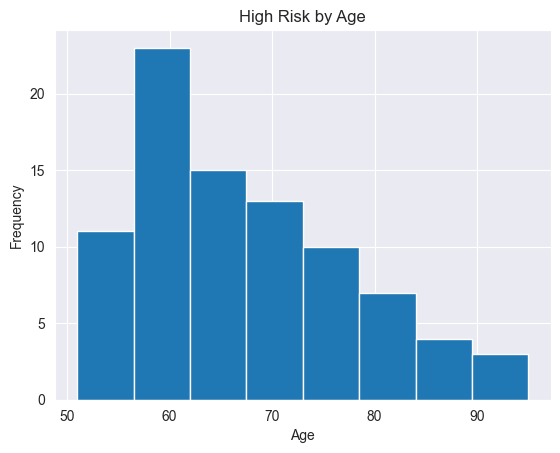

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1,High
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1,Low
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1,High
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1,Low
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0,Low
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0,Low
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0,Low
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0,Low


In [98]:
import matplotlib.pyplot as plt
# Add the 'risk' variable
data_hw['risk'] = data_hw.apply(lambda row: 'High' if row['age'] > 50 and row['serum_creatinine'] > 1.2 else 'Low', axis=1)

# Visualize high risk by age


high_risk = data_hw[data_hw['risk'] == 'High']
plt.hist(high_risk['age'], bins='auto')
plt.title('High Risk by Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
data_hw

preVizualizujte vysoké riziko úmrtia pre jednotlivé vekové skupiny histogramom:

Hint: Použite metódu `hist` z knižnice `matplotlib.pyplot` na vizualizáciu distribúcie veku pre pacientov s vysokým rizikom úmrtia.

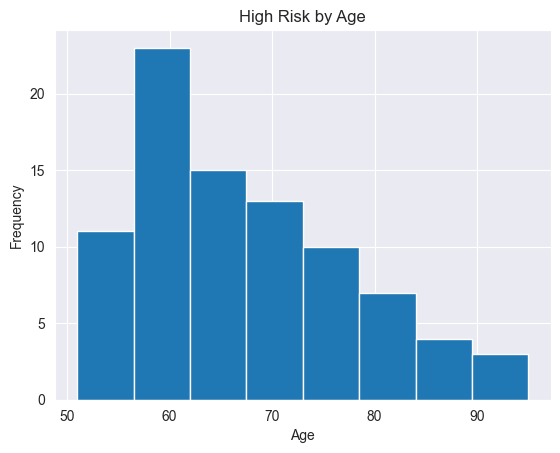

In [88]:
plt.hist(high_risk['age'], bins='auto')
plt.title('High Risk by Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

**V akom veku je riziko zlyhania srdca najväčšie?**

**Koľko záznamov (približne) je v datasete v tejto vekovej kategórii?**

### Úloha 5 (1b)

Analyzujte koreláciu medzi všetkými atribútmi tohto datasetu (napr. vytvorením correlation plot)

Hint: Nenumerické atribúty môžete pred vytvorením korelačnej matice odstrániť.


In [ ]:
# TODO

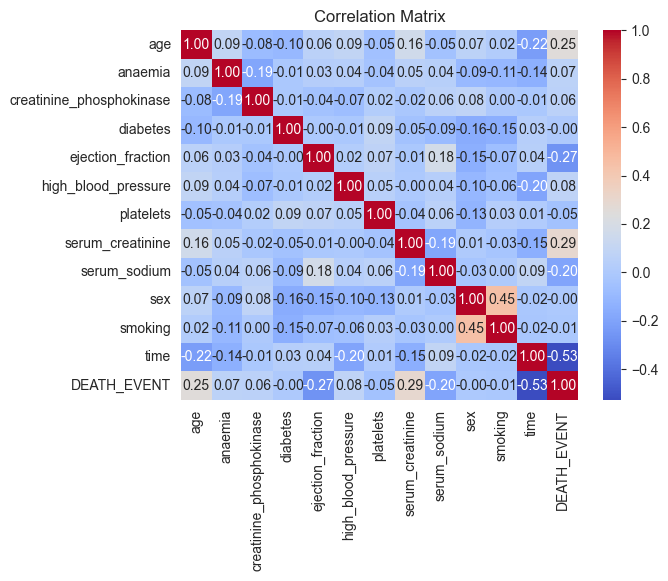

In [95]:
from matplotlib import pyplot as plt
import seaborn as sns


corr_matrix = data_hw.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Ktoré atribúty majú medzi sebou najväčšiu zápornú koreláciu?** (uveďte prvé dve dvojice)

**Ktoré atribúty majú medzi sebou najväčšiu kladnú koreláciu?** (uveďte prvú dvojicu)

----

Viac informácií o zlyhaní srdca: https://www.nhlbi.nih.gov/health/heart-failure